In [1]:
import numpy as np

DIR = "/home/ubuntu/yfcc-scope/embeddings/clip"
centroids = np.load(f"{DIR}/faiss_kmeans_centroids.npy")
assignments = np.load(f"{DIR}/faiss_kmeans_assignments.npy")

In [2]:
assignments.shape, centroids.shape

((9995825,), (10000, 512))

In [3]:
centroids[:10]

array([[ 0.00286249,  0.17538893, -0.13783103, ...,  0.03410513,
        -0.0025394 , -0.01787046],
       [ 0.02724798,  0.05379536, -0.02728214, ..., -0.02109378,
        -0.01257572, -0.02123675],
       [-0.02434753,  0.12213242, -0.03364504, ..., -0.02368119,
         0.01162679,  0.00139579],
       ...,
       [-0.00204038,  0.09081832, -0.0901796 , ...,  0.0129602 ,
         0.00502639, -0.01825567],
       [ 0.0064642 ,  0.13225736, -0.09558472, ...,  0.02304432,
         0.00511134, -0.0345175 ],
       [-0.04429347,  0.10618655, -0.13735093, ..., -0.01276571,
         0.00814471, -0.00350314]], shape=(10, 512), dtype=float32)

In [4]:
k = centroids.shape[0]
n = assignments.shape[0]
counts = np.bincount(assignments, minlength=k)

### Cluster Size Distribution

In [5]:
print(f"n_vectors = {n}, k = {k}")
print(f"mean size = {counts.mean():.1f}, median size = {np.median(counts):.1f}")
print(f"std = {counts.std():.1f}, min = {counts.min()}, max = {counts.max()}")

for p in [0, 1, 5, 25, 50, 75, 95, 99, 100]:
    print(f"p{p:>3}: {np.percentile(counts, p):.0f}")

n_vectors = 9995825, k = 10000
mean size = 999.6, median size = 977.0
std = 290.5, min = 2, max = 3936
p  0: 2
p  1: 360
p  5: 569
p 25: 819
p 50: 977
p 75: 1154
p 95: 1508
p 99: 1896
p100: 3936


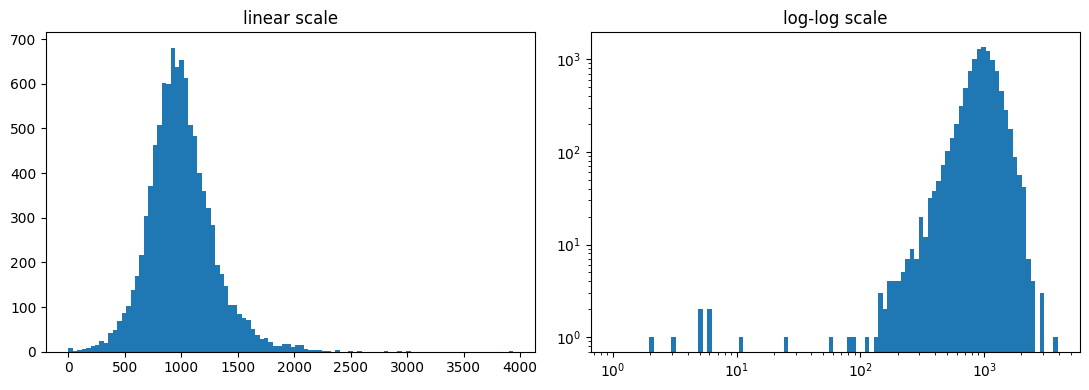

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(counts, bins=100)
axes[0].set_title("linear scale")

axes[1].hist(counts, bins=np.logspace(0, np.log10(counts.max()+1), 100))
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("log-log scale")
plt.tight_layout()
plt.show()

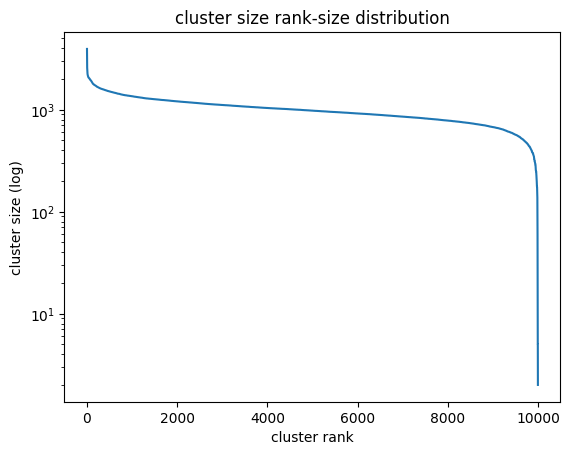

In [7]:
sorted_counts = np.sort(counts)[::-1]
plt.plot(sorted_counts)
plt.yscale("log")
plt.xlabel("cluster rank")
plt.ylabel("cluster size (log)")
plt.title("cluster size rank-size distribution")
plt.show()

### PCA

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame(centroids)
scaler = StandardScaler()
scaled_centroids = scaler.fit_transform(df)

pca = PCA()
reduced_centroids = pca.fit_transform(scaled_centroids)

In [9]:
reduced_centroids

array([[-4.2358547e-01,  5.0052295e+00,  1.5109113e+00, ...,
        -1.5227686e-03, -4.7345090e-04, -2.4135094e-05],
       [-3.6541853e+00, -9.0969505e+00, -1.4068004e+00, ...,
         4.9707401e-03,  1.2505758e-05,  8.3727893e-05],
       [-3.9462845e+00, -1.5344942e-01, -4.1182461e+00, ...,
         2.9977669e-03, -2.0612408e-04,  7.9481993e-05],
       ...,
       [-2.4621036e+00, -5.1310101e+00, -6.5531673e+00, ...,
         2.6292842e-02, -1.3575666e-03,  5.7772864e-05],
       [ 8.6162907e-01,  5.3375763e-01, -8.2325721e-01, ...,
        -6.0900715e-03, -6.5590075e-04,  5.1868279e-05],
       [-2.4444656e+00,  5.4311132e+00, -5.7629137e+00, ...,
         3.4036037e-02,  3.6566329e-04,  1.5012747e-04]],
      shape=(10000, 512), dtype=float32)

In [10]:
df_pca = pd.DataFrame(reduced_centroids[:, :3], columns=["PC1", "PC2", "PC3"])

In [11]:
print("--- Explained Variance Ratio ---")
# Tells you what percentage of information each component contains
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {ratio:.2%}")

total_variance = sum(pca.explained_variance_ratio_)
print(f"Total information retained: {total_variance:.2%}")

--- Explained Variance Ratio ---
Principal Component 1: 6.68%
Principal Component 2: 4.53%
Principal Component 3: 3.10%
Principal Component 4: 2.51%
Principal Component 5: 2.31%
Principal Component 6: 2.14%
Principal Component 7: 2.03%
Principal Component 8: 1.73%
Principal Component 9: 1.66%
Principal Component 10: 1.56%
Principal Component 11: 1.53%
Principal Component 12: 1.50%
Principal Component 13: 1.48%
Principal Component 14: 1.43%
Principal Component 15: 1.29%
Principal Component 16: 1.22%
Principal Component 17: 1.16%
Principal Component 18: 1.11%
Principal Component 19: 1.05%
Principal Component 20: 1.00%
Principal Component 21: 1.00%
Principal Component 22: 0.97%
Principal Component 23: 0.94%
Principal Component 24: 0.90%
Principal Component 25: 0.85%
Principal Component 26: 0.83%
Principal Component 27: 0.79%
Principal Component 28: 0.77%
Principal Component 29: 0.76%
Principal Component 30: 0.74%
Principal Component 31: 0.73%
Principal Component 32: 0.70%
Principal Compon

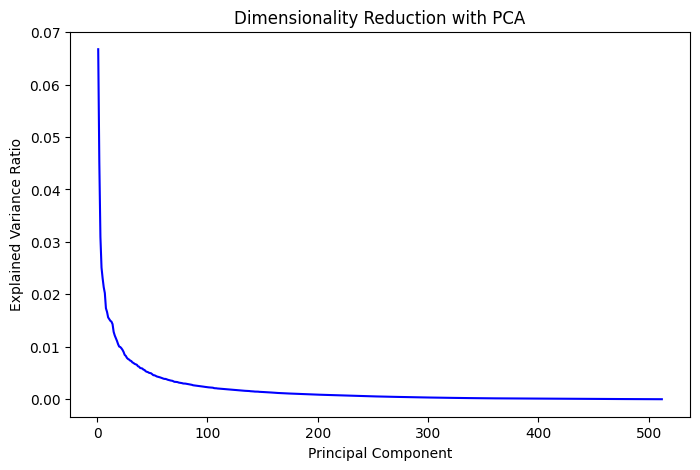

In [12]:
# Plot explained variance ratio
plt.figure(figsize=(8, 5))
x = range(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(x, pca.explained_variance_ratio_, color='b')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Dimensionality Reduction with PCA')
plt.show()

In [13]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
	x=df_pca["PC1"],
	y=df_pca["PC2"],
	z=df_pca["PC3"],
	mode='markers',
	marker=dict(
		size=5,
		color=np.log10(counts + 1),  # Use log scale for color
		colorscale='Viridis',
		opacity=0.8,
		colorbar=dict(title='Cluster Size (log scale)')
	)
)])

fig.update_layout(
	title='3D PCA of Cluster Centroids',
	scene=dict(
		xaxis_title='PC1',
		yaxis_title='PC2',
		zaxis_title='PC3'
	)
)
fig.show()